In [2]:
import json
import re
import numpy as np
import pandas as pd
import re
from scipy.stats import pointbiserialr, spearmanr, ttest_ind, mannwhitneyu
from scipy.stats import pearsonr, spearmanr
import pandas as pd
import pingouin as pg
from tqdm import tqdm
from transformers import AutoTokenizer
import rich

## Data Preparation

In [3]:
with open('/data/user_data/wenkail/sotopia_diplomacy/processed_data_analysis/500_sample_with_taskeval_supply_center_qwen_judge.jsonl', 'r') as f:
    data = [json.loads(line) for line in f]

In [4]:
# Iterate over all games and filter out messages where 'llm_judgement' does not contain exactly 8 yes/no answers
# For parsing, only use the part after </think>
filtered_data = []
not_8_matches_games = []

def extract_answers_after_think(llm_judgement):
    """
    Extracts the 8 yes/no answers after </think> from the llm_judgement string.
    Returns a list of matches (should be length 8 if valid), or [] if not found.
    """
    if not isinstance(llm_judgement, str):
        return []
    # Find the part after </think>
    split = llm_judgement.split("</think>")
    if len(split) < 2:
        return []
    after_think = split[1]
    # Only use the part after </think>
    # Find all lines like "1. Yes", "2. No", etc.
    matches = re.findall(r'\d+\.\s*(yes|no)', after_think.lower())
    return matches

for game in data:
    filtered_game = json.loads(json.dumps(game))  # Deep copy
    for phase in filtered_game.get('phases', []):
        filtered_messages = []
        for msg in phase.get('messages', []):
            if 'llm_judgement' in msg:
                s = msg['llm_judgement']
                matches = extract_answers_after_think(s)
                msg['llm_judgement_matches'] = matches
                if len(matches) == 8:
                    filtered_messages.append(msg)
                else:
                    msg['llm_judgement_matches'] = None
                    not_8_matches_games.append({'game_id': game.get('id'), 'phase': phase.get('name')})
            else:
                filtered_messages.append(msg)
        phase['messages'] = filtered_messages
    filtered_data.append(filtered_game)

# Calculate the proportion of not_8_matches_games
total_messages = 0
for game in data:
    for phase in game.get('phases', []):
        total_messages += len(phase.get('messages', []))

not_8_matches_count = len(not_8_matches_games)
if total_messages > 0:
    ratio = not_8_matches_count / total_messages
else:
    ratio = 0

data = filtered_data
print(f"Number of not_8_matches_games: {not_8_matches_count}")
print(f"Total number of messages: {total_messages}")
print(f"Proportion: {ratio:.2%}")

Number of not_8_matches_games: 13283
Total number of messages: 329454
Proportion: 4.03%


In [5]:
# This is for sender-based features
# Where the prediction target is supply_center

llama3_tokenizer = AutoTokenizer.from_pretrained("/data/models/huggingface/meta-llama/Llama-3.1-8B-Instruct")

# 使用nltk的句子分割
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize

# 特征名映射，和@file_context_0保持一致
feature_name_map = {
    'Ethos': "Ethos (Game-Move + Share-Information)",
    'Logos': "Logos (Reasoning)",
    'Pathos': "Pathos (Rapport~Reassurance)"
}

def count_sentences(text):
    # 使用nltk的句子分割
    if not text or not isinstance(text, str):
        return 0
    sentences = sent_tokenize(text)
    return len(sentences)

results = []
for game in tqdm(data):
    game_id = game.get('id')
    phases = game.get('phases', [])
    # Group phases by year
    year_to_phases = {}
    for phase in phases:
        phase_name = phase.get('name', '')
        m = re.match(r'[SWF](\d{4})', phase_name)
        if not m:
            continue
        year = m.group(1)
        year_to_phases.setdefault(year, []).append(phase)
    # For each year, find the A phase and aggregate the 8 features for all phases in that year
    for year, year_phases in year_to_phases.items():
        # Find the A phase
        a_phase = None
        for phase in year_phases:
            if phase.get('name', '').endswith('A'):
                a_phase = phase
                break
        if a_phase is None:
            continue
        # 对A phase的所有power都记录
        center_info = a_phase.get('center_info', {})
        taskeval_info = a_phase.get('taskeval', {})
        for power, info in center_info.items():
            # 只收集sender为该power的message
            power_messages = []
            feature_sum = np.zeros(8, dtype=int)
            for phase in year_phases:
                for msg in phase.get('messages', []):
                    if msg is None:
                        continue
                    # 只考虑sender为该power的message
                    if msg.get('sender') == power:
                        power_messages.append(msg['message'])
                        s = msg.get('llm_judgement')
                        if not s:
                            continue
                        matches = extract_answers_after_think(s)
                        if len(matches) != 8:
                            continue
                        for i, val in enumerate(matches):
                            if val == 'yes':
                                feature_sum[i] += 1  # sum up
            # 合并所有该power主动发出的message文本
            all_messages_str = "\n".join(power_messages)
            # 跳过all_messages_str为空的情况
            if not all_messages_str.strip():
                continue
            # 计算句子数和token数
            num_sentences = count_sentences(all_messages_str)
            num_tokens = len(llama3_tokenizer.encode(all_messages_str))
            # Ethos: Game-Move(0) + Share-Information(7) sum
            ethos = feature_sum[0] + feature_sum[7]
            # Logos: Reasoning(1) sum
            logos = feature_sum[1]
            # Pathos: Rapport(2), Apologies(3), Compliment(4), Personal-Thoughts(5), Reassurance(6) sum
            pathos = np.sum(feature_sum[2:7])
            supply_gain = info.get('center_increase')
            taskeval_val = taskeval_info.get(power, np.nan)
            # message放在最前面，前面加上num_sentences, num_tokens
            results.append([num_sentences, num_tokens, all_messages_str, game_id, a_phase.get('name', ''), power, ethos, logos, pathos, supply_gain, taskeval_val])

# Build DataFrame
cols = ['num_sentences', 'num_tokens', 'messages', 'game_id', 'phase_name', 'power', 'Ethos', 'Logos', 'Pathos', 'supply_gain', 'taskeval']
df_nego_eval_sum = pd.DataFrame(results, columns=cols)

# # 应用特征名映射
# df_nego_eval_sum = df_nego_eval_sum.rename(columns=feature_name_map)

[nltk_data] Downloading package punkt to /home/wenkail/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
100%|██████████| 471/471 [00:32<00:00, 14.36it/s]


In [6]:
# This is for sender-based features
# Where the prediction target is supply_center

llama3_tokenizer = AutoTokenizer.from_pretrained("/data/models/huggingface/meta-llama/Llama-3.1-8B-Instruct")

# 使用nltk的句子分割
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize

# 特征名映射，和@file_context_0保持一致
feature_name_map = {
    'Ethos': "Ethos (Game-Move + Share-Information)",
    'Logos': "Logos (Reasoning)",
    'Pathos': "Pathos (Rapport~Reassurance)"
}

def count_sentences(text):
    # 使用nltk的句子分割
    if not text or not isinstance(text, str):
        return 0
    sentences = sent_tokenize(text)
    return len(sentences)

results = []
for game in tqdm(data):
    game_id = game.get('id')
    phases = game.get('phases', [])
    # Group phases by year
    year_to_phases = {}
    for phase in phases:
        phase_name = phase.get('name', '')
        m = re.match(r'[SWF](\d{4})', phase_name)
        if not m:
            continue
        year = m.group(1)
        year_to_phases.setdefault(year, []).append(phase)
    # For each year, find the A phase and aggregate the 8 features for all phases in that year
    for year, year_phases in year_to_phases.items():
        # Find the A phase
        a_phase = None
        for phase in year_phases:
            if phase.get('name', '').endswith('A'):
                a_phase = phase
                break
        if a_phase is None:
            continue
        # 对A phase的所有power都记录
        center_info = a_phase.get('center_info', {})
        taskeval_info = a_phase.get('taskeval', {})
        for power, info in center_info.items():
            # 只收集sender为该power的message
            power_messages = []
            yes_any = np.zeros(8, dtype=int)
            for phase in year_phases:
                for msg in phase.get('messages', []):
                    if msg is None:
                        continue
                    # 只考虑sender为该power的message
                    if msg.get('sender') == power:
                        power_messages.append(msg['message'])
                        s = msg.get('llm_judgement')
                        if not s:
                            continue
                        matches = extract_answers_after_think(s)
                        if len(matches) != 8:
                            continue
                        for i, val in enumerate(matches):
                            if val == 'yes':
                                yes_any[i] = 1  # 只要有一次yes就为1
            # 合并所有该power主动发出的message文本
            all_messages_str = "\n".join(power_messages)
            # 跳过all_messages_str为空的情况
            if not all_messages_str.strip():
                continue
            # 计算句子数和token数
            num_sentences = count_sentences(all_messages_str)
            num_tokens = len(llama3_tokenizer.encode(all_messages_str))
            # Ethos: Game-Move(0) or Share-Information(7)有yes就为1
            ethos = int(yes_any[0] == 1 or yes_any[7] == 1)
            # Logos: Reasoning(1)有yes就为1
            logos = int(yes_any[1] == 1)
            # Pathos: Rapport(2), Apologies(3), Compliment(4), Personal-Thoughts(5), Reassurance(6)有任意yes就为1
            pathos = int(np.any(yes_any[2:7]))
            supply_gain = info.get('center_increase')
            taskeval_val = taskeval_info.get(power, np.nan)
            # message放在最前面，前面加上num_sentences, num_tokens
            results.append([num_sentences, num_tokens, all_messages_str, game_id, a_phase.get('name', ''), power, ethos, logos, pathos, supply_gain, taskeval_val])

# Build DataFrame
cols = ['num_sentences', 'num_tokens', 'messages', 'game_id', 'phase_name', 'power', 'Ethos', 'Logos', 'Pathos', 'supply_gain', 'taskeval']
df_nego_eval_binary = pd.DataFrame(results, columns=cols)

# # 应用特征名映射
# df_nego_eval_binary = df_nego_eval_binary.rename(columns=feature_name_map)

[nltk_data] Downloading package punkt to /home/wenkail/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
100%|██████████| 471/471 [00:33<00:00, 14.27it/s]


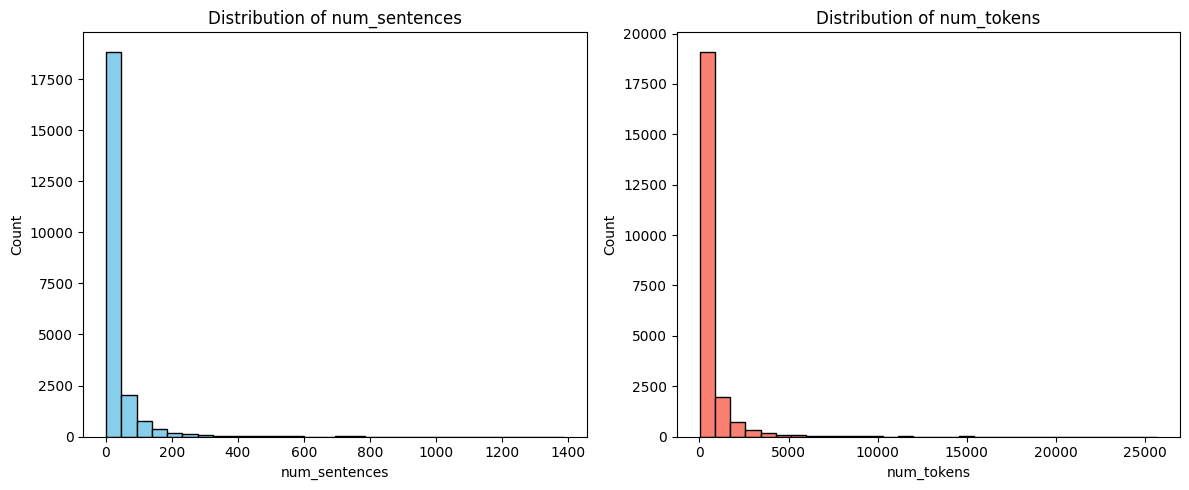

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_nego_eval_sum['num_sentences'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of num_sentences')
axes[0].set_xlabel('num_sentences')
axes[0].set_ylabel('Count')

axes[1].hist(df_nego_eval_sum['num_tokens'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Distribution of num_tokens')
axes[1].set_xlabel('num_tokens')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [8]:
import seaborn as sns
from scipy.optimize import curve_fit
import numpy as np

feature_cols = [
    'Ethos',
    'Logos',
    'Pathos'
]

def plot_negotiation_feature_statistics(df_nego_eval_sum, feature_cols):
    """
    Visualize and analyze the distribution and correlation of negotiation features.
    """
    # 1. Bar plot: total occurrences of each negotiation feature
    plt.figure(figsize=(10, 5))
    df_nego_eval_sum[feature_cols].sum().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title("Total Occurrences of Each Negotiation Feature")
    plt.ylabel("Count")
    plt.xlabel("Negotiation Feature")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    # 2. Nonlinear fit: feature count vs. num_sentences
    def nonlinear_func(x, a, b, c):
        # Simple quadratic function for nonlinear fitting
        return a * x**2 + b * x + c

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    for i, feat in enumerate(feature_cols):
        ax = axes[i // 4, i % 4]
        x = df_nego_eval_sum[feat].values
        y = df_nego_eval_sum['num_sentences'].values

        # Scatter plot
        ax.scatter(x, y, alpha=0.5, label='num_sentences', color='skyblue', edgecolor='k')

        # Nonlinear fit
        try:
            mask = ~np.isnan(x) & ~np.isnan(y)
            popt, _ = curve_fit(nonlinear_func, x[mask], y[mask], maxfev=10000)
            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = nonlinear_func(x_fit, *popt)
            ax.plot(x_fit, y_fit, color='red', label='Nonlinear Fit')
        except Exception:
            pass  # Skip if fitting fails

        ax.set_title(f"{feat} vs. num_sentences (Nonlinear Fit)")
        ax.set_xlabel(f"{feat} Count")
        ax.set_ylabel("Number of Sentences")
        ax.legend()
    plt.tight_layout()
    plt.show()

    # 3. Scatter: feature count vs. num_sentences and num_tokens
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    for i, feat in enumerate(feature_cols):
        ax = axes[i // 4, i % 4]
        sns.scatterplot(
            x=df_nego_eval_sum[feat], 
            y=df_nego_eval_sum['num_sentences'], 
            ax=ax, 
            alpha=0.6, 
            label='num_sentences'
        )
        sns.scatterplot(
            x=df_nego_eval_sum[feat], 
            y=df_nego_eval_sum['num_tokens'], 
            ax=ax, 
            alpha=0.6, 
            label='num_tokens'
        )
        ax.set_title(f"{feat} vs. num_sentences/num_tokens")
        ax.set_xlabel(f"{feat} Count")
        ax.set_ylabel("Value")
        ax.legend()
    plt.tight_layout()
    plt.show()

    # 4. Pearson correlation coefficients
    print("Pearson correlation coefficients between features and num_sentences/num_tokens:")
    for feat in feature_cols:
        corr_sent = df_nego_eval_sum[[feat, 'num_sentences']].corr().iloc[0,1]
        corr_token = df_nego_eval_sum[[feat, 'num_tokens']].corr().iloc[0,1]
        print(f"{feat}: correlation with num_sentences = {corr_sent:.3f}, correlation with num_tokens = {corr_token:.3f}")

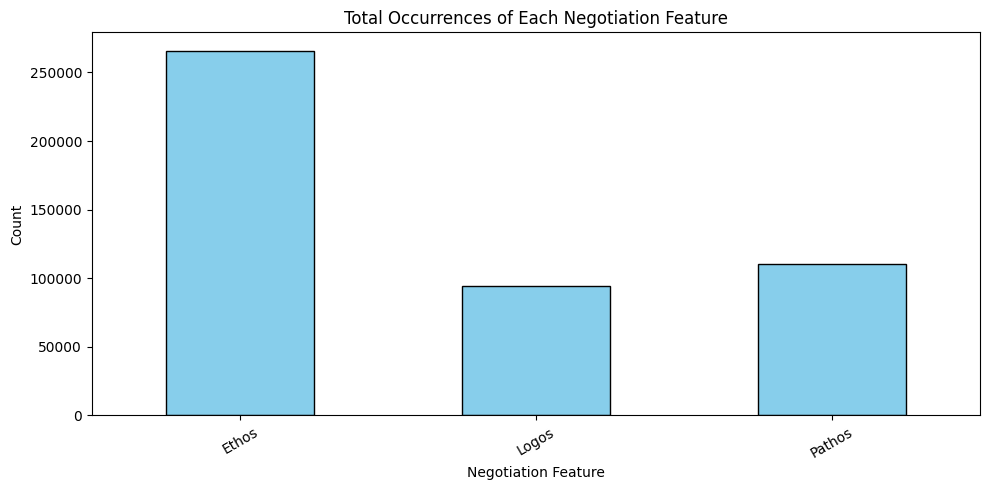

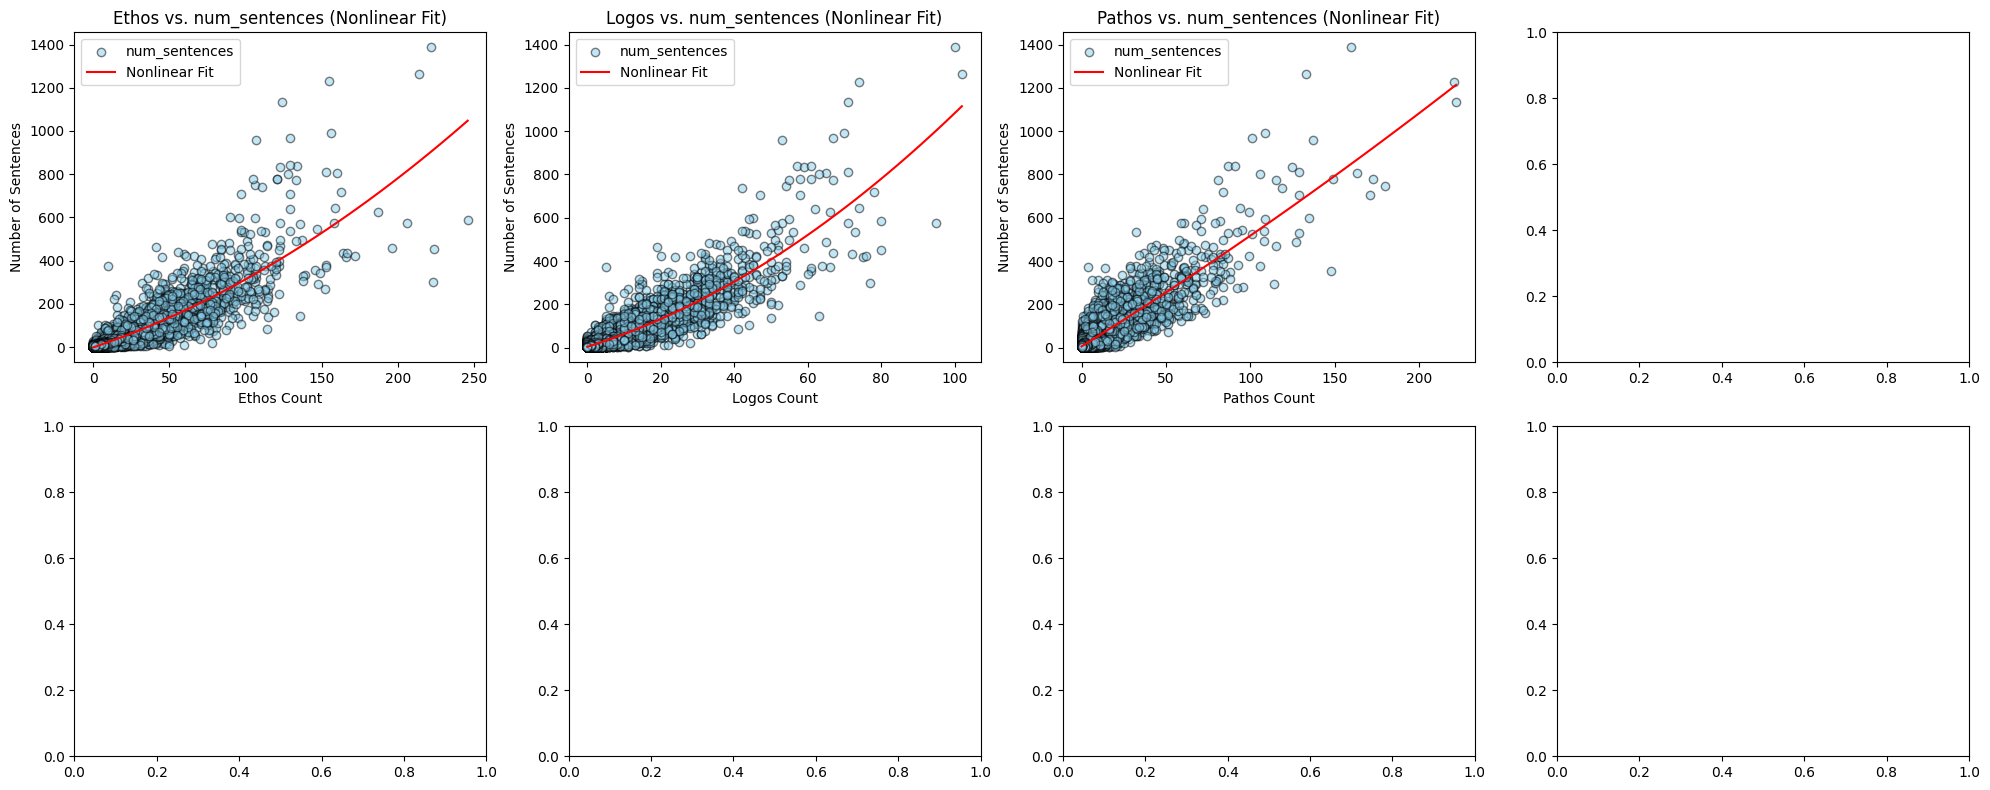

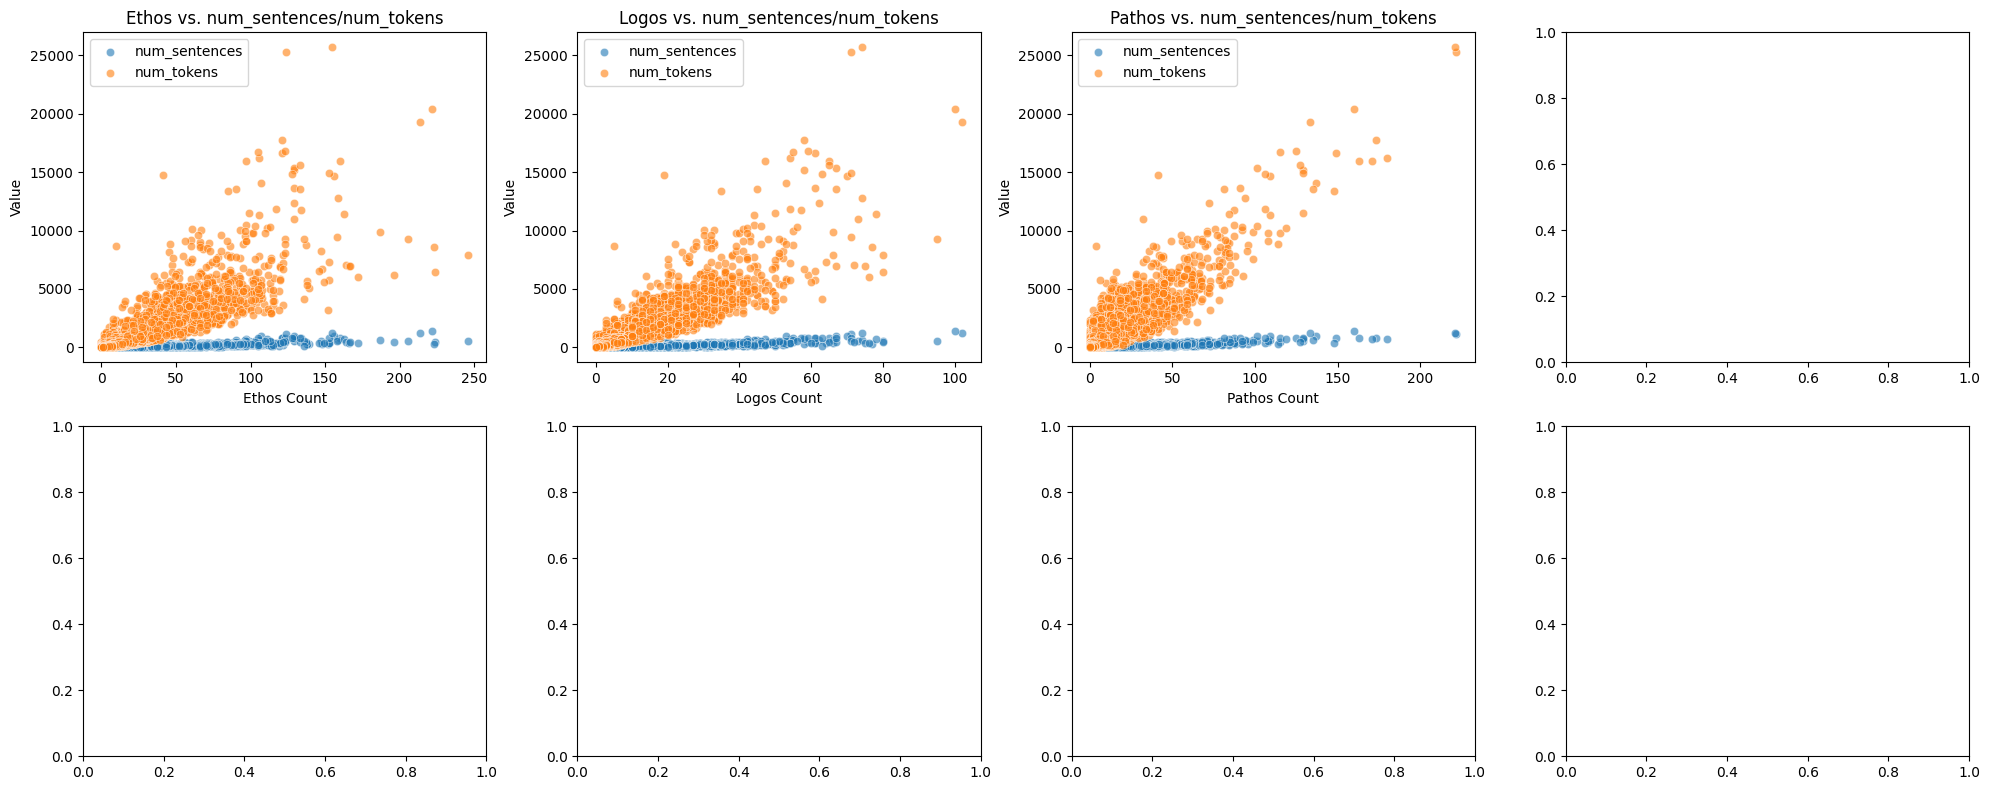

Pearson correlation coefficients between features and num_sentences/num_tokens:
Ethos: correlation with num_sentences = 0.878, correlation with num_tokens = 0.858
Logos: correlation with num_sentences = 0.892, correlation with num_tokens = 0.888
Pathos: correlation with num_sentences = 0.867, correlation with num_tokens = 0.886


In [9]:
plot_negotiation_feature_statistics(df_nego_eval_sum, feature_cols)

### Correlation Comparasion

#### Sum vs Binary Negotiation Features

In [10]:
def correlation_effectsize_summary(df):
    """
    计算二元特征与supply_gain的相关性和效应量统计，返回DataFrame。
    """
    selected_features = [
        "Ethos", "Logos", "Pathos",
        "num_sentences", "num_tokens"
    ]

    records = []
    for feat in selected_features:
        valid = df[[feat, 'supply_gain']].dropna()
        if valid[feat].nunique() < 2:
            continue
        r_pearson, p_pearson = pearsonr(valid[feat], valid['supply_gain'])
        r_spearman, p_spearman = spearmanr(valid[feat], valid['supply_gain'])
        records.append(dict(
            feature=feat,
            pearson_r=round(r_pearson, 3),
            p_pearson=round(p_pearson, 4),
            spearman_r=round(r_spearman, 3),
            p_spearman=round(p_spearman, 4),
        ))

    corr_df = pd.DataFrame(records).set_index('feature')
    print("\n=== Correlation summary (all features + num_sentences/num_tokens) ===")
    print(corr_df)
    return corr_df

# 调用方法
print("=== Sum version ===")
feature_sum_correlation = correlation_effectsize_summary(df_nego_eval_sum)
print("\n")
print("=== Binary version ===")
feature_binary_correlation = correlation_effectsize_summary(df_nego_eval_binary)
print("\n")

=== Sum version ===

=== Correlation summary (all features + num_sentences/num_tokens) ===
               pearson_r  p_pearson  spearman_r  p_spearman
feature                                                    
Ethos              0.160        0.0       0.246         0.0
Logos              0.130        0.0       0.191         0.0
Pathos             0.139        0.0       0.201         0.0
num_sentences      0.119        0.0       0.225         0.0
num_tokens         0.110        0.0       0.222         0.0


=== Binary version ===

=== Correlation summary (all features + num_sentences/num_tokens) ===
               pearson_r  p_pearson  spearman_r  p_spearman
feature                                                    
Ethos              0.135        0.0       0.142         0.0
Logos              0.147        0.0       0.154         0.0
Pathos             0.148        0.0       0.158         0.0
num_sentences      0.119        0.0       0.225         0.0
num_tokens         0.110        0

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_correlation_heatmap(df, title, feature_cols=None, feature_labels=None, method='pearson', figsize=(8, 6)):
    """
    计算各个features之间的相关性，并画出相关性矩阵热力图

    Args:
        df: DataFrame，包含特征的表
        feature_cols: list，特征列名
        feature_labels: list，热力图显示的label
        method: str，相关性计算方法
        figsize: tuple，图像大小
        title: str，图标题
    """
    if feature_cols is None:
        feature_cols = [
            'Ethos', 'Logos', 'Pathos',
            "num_sentences", "num_tokens"
        ]
    if feature_labels is None:
        feature_labels = [
            'Ethos', 'Logos', 'Pathos',
            "Num Sentences", "Num Tokens"
        ]
    # 计算相关性矩阵
    corr_matrix = df[feature_cols].corr(method=method)

    # print(f"\n=== Features Correlation Matrix ({method.capitalize()}) ===")
    # print(corr_matrix.round(2))

    plt.figure(figsize=figsize)
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap="coolwarm", 
        square=True, 
        cbar=True,
        xticklabels=feature_labels,
        yticklabels=feature_labels
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()


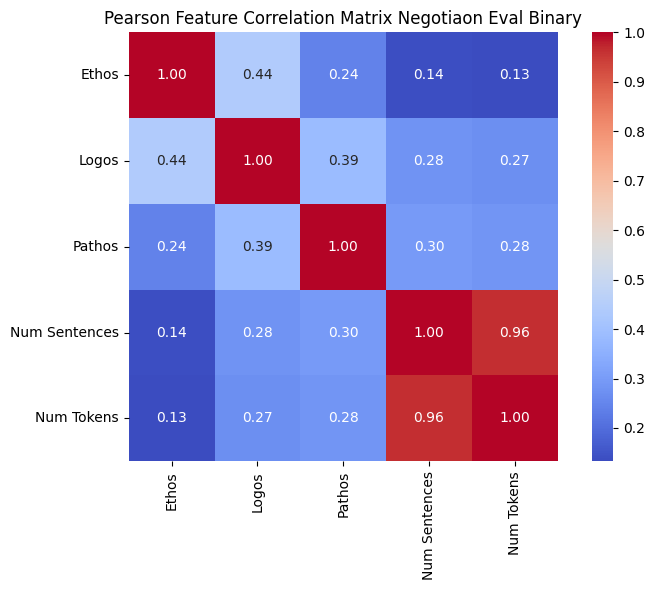

In [12]:
# 调用方法示例
plot_feature_correlation_heatmap(df_nego_eval_binary, "Pearson Feature Correlation Matrix Negotiaon Eval Binary")

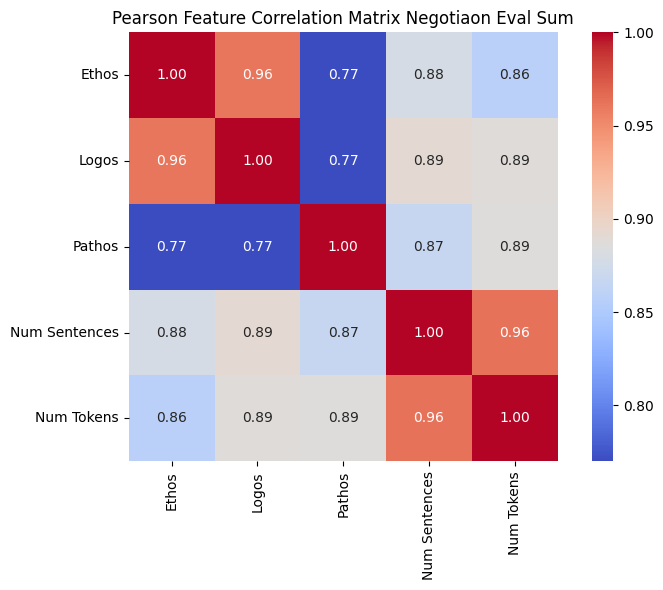

In [13]:
# 调用方法示例
plot_feature_correlation_heatmap(df_nego_eval_sum, "Pearson Feature Correlation Matrix Negotiaon Eval Sum")

In [14]:
def print_correlation_tables_by_bin(
    df, 
    feature_cols, 
    target_col, 
    bin_col, 
    bin_percentiles=None, 
    min_bin_size=10, 
    default_bins=None, 
    bin_title="",
):
    """
    For each bin of bin_col, print a full correlation table (Pearson & Spearman) for feature_cols vs target_col.
    """
    import numpy as np
    import pandas as pd
    from scipy.stats import pearsonr, spearmanr

    if bin_percentiles is None:
        bin_percentiles = [0, 20, 40, 60, 80, 100]
    # 1. Binning
    bins = np.unique(np.percentile(df[bin_col], bin_percentiles).astype(int))
    if len(np.unique(bins)) < 2 and default_bins is not None:
        bins = default_bins
    df = df.copy()
    df[f"{bin_col}_bin"] = pd.cut(df[bin_col], bins=bins, right=False, include_lowest=True)

    print(f"=== Correlation with {target_col} under different {bin_col} bins (auto-binning, Pearson & Spearman) ===")
    corrs_pearson = []
    corrs_spearman = []
    labels = []
    for bin_interval in df[f"{bin_col}_bin"].cat.categories:
        sub_df = df[df[f"{bin_col}_bin"] == bin_interval]
        if len(sub_df) < min_bin_size:
            continue  # skip bins with too few samples
        pearson_row = []
        spearman_row = []
        for feat in feature_cols:
            valid = sub_df[[feat, target_col]].dropna()
            if valid[feat].nunique() < 2:
                pearson_row.append(np.nan)
                spearman_row.append(np.nan)
                continue
            r_pearson, p_pearson = pearsonr(valid[feat], valid[target_col])
            r_spearman, p_spearman = spearmanr(valid[feat], valid[target_col])
            pearson_row.append((r_pearson, p_pearson))
            spearman_row.append((r_spearman, p_spearman))
        corr_table = pd.DataFrame({
            "Feature": feature_cols,
            "Pearson r": [round(x[0], 3) if x is not np.nan else np.nan for x in pearson_row],
            "Pearson p": [round(x[1], 4) if x is not np.nan else np.nan for x in pearson_row],
            "Spearman r": [round(x[0], 3) if x is not np.nan else np.nan for x in spearman_row],
            "Spearman p": [round(x[1], 4) if x is not np.nan else np.nan for x in spearman_row],
        }).set_index("Feature")
        print(f"\n=== Correlation Table for {bin_title or bin_col} in {bin_interval} (n={len(sub_df)}) ===")
        print(corr_table)
        corrs_pearson.append([x[0] if x is not np.nan else np.nan for x in pearson_row])
        corrs_spearman.append([x[0] if x is not np.nan else np.nan for x in spearman_row])
        labels.append(str(bin_interval))
    return corrs_pearson, corrs_spearman, labels


In [15]:
# This is a results for binary negotiation evaluation.

feature_cols = [
    'Ethos',
    'Logos',
    'Pathos'
]
corrs_sent_pearson, corrs_sent_spearman, labels_sent = print_correlation_tables_by_bin(
    df_nego_eval_binary,
    feature_cols=feature_cols,
    target_col='supply_gain',
    bin_col='num_sentences',
    bin_percentiles=[0, 20, 40, 60, 80, 100],
    min_bin_size=10,
    default_bins=[0, 2, 4, 6, 10, 100],
    bin_title="num_sentences"
)

corrs_tok_pearson, corrs_tok_spearman, labels_tok = print_correlation_tables_by_bin(
    df_nego_eval_binary,
    feature_cols=feature_cols,
    target_col='supply_gain',
    bin_col='num_tokens',
    bin_percentiles=[0, 20, 40, 60, 80, 100],
    min_bin_size=10,
    default_bins=[0, 20, 40, 60, 100, 1000],
    bin_title="num_tokens"
)

=== Correlation with supply_gain under different num_sentences bins (auto-binning, Pearson & Spearman) ===

=== Correlation Table for num_sentences in [1, 3) (n=3539) ===
         Pearson r  Pearson p  Spearman r  Spearman p
Feature                                              
Ethos        0.081     0.0000       0.091      0.0000
Logos        0.058     0.0005       0.065      0.0001
Pathos       0.039     0.0193       0.045      0.0068

=== Correlation Table for num_sentences in [3, 8) (n=5282) ===
         Pearson r  Pearson p  Spearman r  Spearman p
Feature                                              
Ethos        0.096     0.0000       0.102      0.0000
Logos        0.032     0.0197       0.037      0.0070
Pathos       0.047     0.0006       0.053      0.0001

=== Correlation Table for num_sentences in [8, 17) (n=4688) ===
         Pearson r  Pearson p  Spearman r  Spearman p
Feature                                              
Ethos        0.072     0.0000       0.066      0.000

In [16]:
# This is a results for discrete negotiation evaluation.

feature_cols = [
    'Ethos',
    'Logos',
    'Pathos'
]
corrs_sent_pearson, corrs_sent_spearman, labels_sent = print_correlation_tables_by_bin(
    df_nego_eval_sum,
    feature_cols=feature_cols,
    target_col='supply_gain',
    bin_col='num_sentences',
    bin_percentiles=[0, 20, 40, 60, 80, 100],
    min_bin_size=10,
    default_bins=[0, 2, 4, 6, 10, 100],
    bin_title="num_sentences"
)

corrs_tok_pearson, corrs_tok_spearman, labels_tok = print_correlation_tables_by_bin(
    df_nego_eval_sum,
    feature_cols=feature_cols,
    target_col='supply_gain',
    bin_col='num_tokens',
    bin_percentiles=[0, 20, 40, 60, 80, 100],
    min_bin_size=10,
    default_bins=[0, 20, 40, 60, 100, 1000],
    bin_title="num_tokens"
)

=== Correlation with supply_gain under different num_sentences bins (auto-binning, Pearson & Spearman) ===

=== Correlation Table for num_sentences in [1, 3) (n=3539) ===
         Pearson r  Pearson p  Spearman r  Spearman p
Feature                                              
Ethos        0.103     0.0000       0.115       0.000
Logos        0.065     0.0001       0.068       0.000
Pathos       0.061     0.0003       0.052       0.002

=== Correlation Table for num_sentences in [3, 8) (n=5282) ===
         Pearson r  Pearson p  Spearman r  Spearman p
Feature                                              
Ethos        0.129     0.0000       0.151      0.0000
Logos        0.054     0.0001       0.049      0.0004
Pathos       0.059     0.0000       0.059      0.0000

=== Correlation Table for num_sentences in [8, 17) (n=4688) ===
         Pearson r  Pearson p  Spearman r  Spearman p
Feature                                              
Ethos        0.115     0.0000       0.132      0.000

## Logistic Regression

### XGBoost


Tuning and evaluating: LogisticRegression


Fitting LogisticRegression:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting 5 folds for each of 15 candidates, totalling 75 fits


/home/wenkail/miniconda3/envs/inf/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/wenkail/miniconda3/envs/inf/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/

Best params: {'logreg__C': 1, 'poly__degree': 3}
Best CV ROC-AUC: 0.642


...

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'gb__learning_rate': 0.005, 'gb__max_depth': 3}
Best CV ROC-AUC: 0.642


CV predict GradientBoosting:   0%|          | 0/5 [00:00<?, ?it/s]

Best CV Accuracy : 0.601
Best CV Precision: 0.575  Recall: 0.509  F1: 0.540
Best CV ROC-AUC  : 0.641

Selected best model: LogisticRegression


Final fit LogisticRegression:   0%|          | 0/1 [00:00<?, ?it/s]


Final Hold-out Results:
Accuracy : 0.603
Precision: 0.576  Recall: 0.526  F1: 0.550
ROC-AUC  : 0.636

Classification Report:
               precision    recall  f1-score   support

     No Gain       0.62      0.67      0.65      2431
        Gain       0.58      0.53      0.55      2075

    accuracy                           0.60      4506
   macro avg       0.60      0.60      0.60      4506
weighted avg       0.60      0.60      0.60      4506



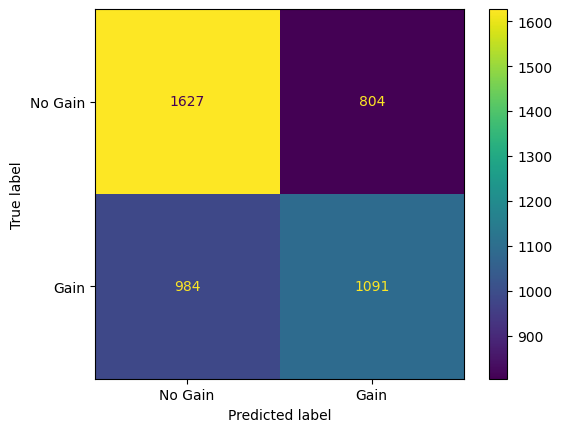


Logistic Regression Coefficients (absolute value) (sorted by importance ratio):
Feature                                    Importance        Ratio
Ethos                                        1.549337     11.3389%
num_tokens                                  -1.106906      8.1010%
Ethos Logos                                 -0.853031      6.2430%
Ethos^2 Logos                                0.771553      5.6467%
Ethos Logos^2                               -0.726233      5.3150%
Logos                                       -0.615435      4.5041%
Pathos                                       0.573688      4.1986%
num_tokens Ethos                             0.559935      4.0979%
num_tokens num_sentences Logos               0.532792      3.8993%
Logos^2                                      0.450728      3.2987%
num_tokens Logos                             0.393330      2.8786%
num_sentences Ethos Logos                    0.365960      2.6783%
num_tokens num_sentences Ethos              -0.3

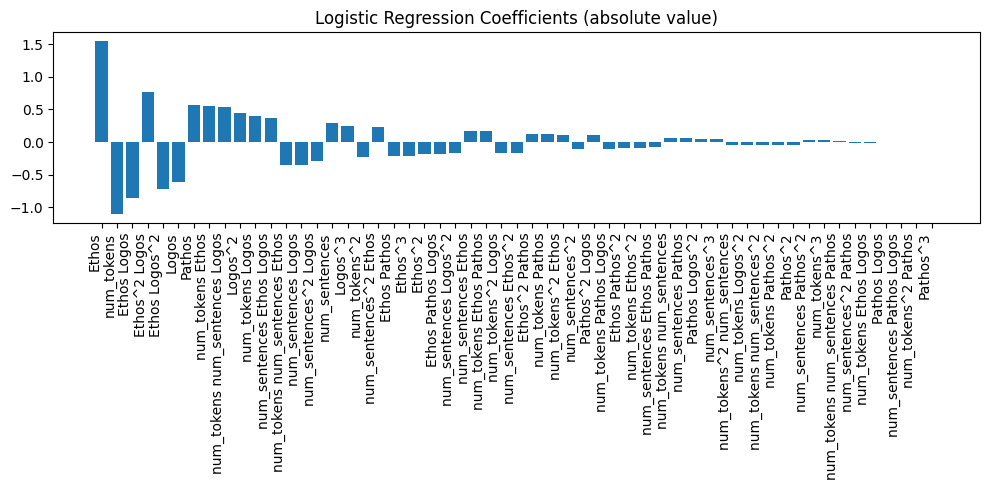


Feature importance ratio (Logistic Regression):
Ethos: 11.3389%
num_tokens: 8.1010%
Ethos Logos: 6.2430%
Ethos^2 Logos: 5.6467%
Ethos Logos^2: 5.3150%
Logos: 4.5041%
Pathos: 4.1986%
num_tokens Ethos: 4.0979%
num_tokens num_sentences Logos: 3.8993%
Logos^2: 3.2987%
num_tokens Logos: 2.8786%
num_sentences Ethos Logos: 2.6783%
num_tokens num_sentences Ethos: 2.6128%
num_sentences Logos: 2.5435%
num_sentences^2 Logos: 2.1737%
num_sentences: 2.1719%
Logos^3: 1.8250%
num_tokens^2: 1.6571%
num_sentences^2 Ethos: 1.6409%
Ethos Pathos: 1.5899%
Ethos^3: 1.5416%
Ethos^2: 1.3825%
Ethos Pathos Logos: 1.3270%
num_sentences Logos^2: 1.2824%
num_sentences Ethos: 1.2673%
num_tokens Ethos Pathos: 1.2266%
num_tokens^2 Logos: 1.1937%
num_sentences Ethos^2: 1.1878%
Ethos^2 Pathos: 0.9533%
num_tokens Pathos: 0.8588%
num_tokens^2 Ethos: 0.8350%
num_sentences^2: 0.8153%
Pathos^2 Logos: 0.8111%
num_tokens Pathos Logos: 0.8056%
Ethos Pathos^2: 0.6990%
num_tokens Ethos^2: 0.6531%
num_sentences Ethos Pathos: 0.5

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report)
import matplotlib.pyplot as plt
import os

# 解决 huggingface/tokenizers 并行警告
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# 加载tqdm用于进度条
from tqdm.auto import tqdm

# --- 1. Prepare data --------------------------------------------------------
df   = df_nego_eval_sum.copy()
cols = ["num_tokens", "num_sentences",
        "Ethos", "Pathos", "Logos",]

df = df.dropna(subset=cols + ["supply_gain"])
X  = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y  = (df["supply_gain"] > 0).astype(int)

# --- 2. Cross-validation and Model Selection --------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Try several models and hyperparameters
models = {
    "LogisticRegression": Pipeline([
        ("scale", StandardScaler()),
        ("poly", PolynomialFeatures(degree=4, include_bias=False)),  # degree更大
        ("logreg", LogisticRegression(max_iter=10000, solver="lbfgs", class_weight="balanced"))
    ]),
    "RandomForest": Pipeline([
        ("scale", StandardScaler()),
        ("rf", RandomForestClassifier(n_estimators=1000, class_weight="balanced", random_state=42))
    ]),
    "GradientBoosting": Pipeline([
        ("scale", StandardScaler()),
        ("gb", GradientBoostingClassifier(n_estimators=1000, learning_rate=0.01, random_state=42))
    ])
}

param_grids = {
    "LogisticRegression": {
        "poly__degree": [2, 3, 4],  # 更高阶
        "logreg__C": [0.01, 0.1, 1, 10, 100] # 
    },
    "RandomForest": {
        "rf__max_depth": [5, 8, 12, 16, 20, None],  # 更深
        "rf__min_samples_split": [2, 5, 10, 20]
    },
    "GradientBoosting": {
        "gb__max_depth": [3, 5, 8, 12],  # 更深
        "gb__learning_rate": [0.005, 0.01, 0.02, 0.05]
    }
}

best_models = {}
best_scores = {}
cv_metrics = {}

for name, model in models.items():
    print(f"\nTuning and evaluating: {name}")
    grid = GridSearchCV(model, param_grids[name], cv=skf, scoring="roc_auc", n_jobs=-1, verbose=1, return_train_score=False)
    # 用tqdm包装fit
    with tqdm(total=1, desc=f"Fitting {name}", leave=True) as pbar:
        grid.fit(X, y)
        pbar.update(1)
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

    # 计算其他CV指标
    # 取最佳参数下的cross_val预测
    from sklearn.model_selection import cross_val_predict
    best_estimator = grid.best_estimator_
    # cross_val_predict本身没有进度条，这里用tqdm包装skf.split
    y_pred_cv = np.zeros_like(y)
    y_prob_cv = np.zeros_like(y, dtype=float)
    splits = list(skf.split(X, y))
    for i, (train_idx, test_idx) in enumerate(tqdm(splits, desc=f"CV predict {name}", leave=False)):
        best_estimator.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred_cv[test_idx] = best_estimator.predict(X.iloc[test_idx])
        if hasattr(best_estimator, "predict_proba"):
            y_prob_cv[test_idx] = best_estimator.predict_proba(X.iloc[test_idx])[:, 1]
        else:
            prob = best_estimator.decision_function(X.iloc[test_idx])
            prob = (prob - prob.min()) / (prob.max() - prob.min() + 1e-8)
            y_prob_cv[test_idx] = prob

    acc_cv = accuracy_score(y, y_pred_cv)
    prec_cv, rec_cv, f1_cv, _ = precision_recall_fscore_support(y, y_pred_cv, average="binary")
    auc_cv = roc_auc_score(y, y_prob_cv)
    print(f"Best CV Accuracy : {acc_cv:.3f}")
    print(f"Best CV Precision: {prec_cv:.3f}  Recall: {rec_cv:.3f}  F1: {f1_cv:.3f}")
    print(f"Best CV ROC-AUC  : {auc_cv:.3f}")

    best_models[name] = grid.best_estimator_
    best_scores[name] = grid.best_score_
    cv_metrics[name] = {
        "accuracy": acc_cv,
        "precision": prec_cv,
        "recall": rec_cv,
        "f1": f1_cv,
        "roc_auc": auc_cv
    }

# --- 3. Final evaluation on hold-out set ------------------------------------
# Use the best model (choose the one with highest CV ROC-AUC)
best_name = max(best_scores, key=lambda n: best_scores[n])
final_model = best_models[best_name]
print(f"\nSelected best model: {best_name}")

# Hold-out test set
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y)
with tqdm(total=1, desc=f"Final fit {best_name}", leave=True) as pbar:
    final_model.fit(X_tr, y_tr)
    pbar.update(1)
y_pred  = final_model.predict(X_te)
if hasattr(final_model, "predict_proba"):
    y_prob = final_model.predict_proba(X_te)[:, 1]
else:
    # For models without predict_proba (e.g., SVM), use decision_function
    y_prob = final_model.decision_function(X_te)
    y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-8)

acc = accuracy_score(y_te, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred, average="binary")
auc = roc_auc_score(y_te, y_prob)

print(f"\nFinal Hold-out Results:")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}")
print(f"ROC-AUC  : {auc:.3f}")
print("\nClassification Report:\n", classification_report(y_te, y_pred, target_names=["No Gain", "Gain"]))

cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=["No Gain", "Gain"])
disp.plot()
plt.show()

# Feature importance (if available) + 输出每个feature的重要程度占比
def print_feature_importance_ratio(importances, feat_names, title="Feature Importances"):
    importances = np.array(importances)
    total = np.sum(np.abs(importances))
    if total == 0:
        ratios = np.zeros_like(importances)
    else:
        ratios = np.abs(importances) / total
    sorted_idx = np.argsort(ratios)[::-1]
    print(f"\n{title} (sorted by importance ratio):")
    print("{:<40s} {:>12s} {:>12s}".format("Feature", "Importance", "Ratio"))
    for idx in sorted_idx:
        print("{:<40s} {:12.6f} {:12.4%}".format(str(feat_names[idx]), importances[idx], ratios[idx]))
    return ratios, sorted_idx

if hasattr(final_model.named_steps.get("rf", None), "feature_importances_"):
    importances = final_model.named_steps["rf"].feature_importances_
    feat_names = X.columns
    ratios, sorted_idx = print_feature_importance_ratio(importances, feat_names, title="Random Forest Feature Importances")
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(importances)), importances[sorted_idx])
    plt.xticks(range(len(importances)), feat_names[sorted_idx], rotation=45, ha="right")
    plt.title("Random Forest Feature Importances")
    plt.tight_layout()
    plt.show()
    # 输出占比
    print("\nFeature importance ratio (Random Forest):")
    for idx in sorted_idx:
        print(f"{feat_names[idx]}: {ratios[idx]:.4%}")
elif hasattr(final_model.named_steps.get("gb", None), "feature_importances_"):
    importances = final_model.named_steps["gb"].feature_importances_
    feat_names = X.columns
    ratios, sorted_idx = print_feature_importance_ratio(importances, feat_names, title="Gradient Boosting Feature Importances")
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(importances)), importances[sorted_idx])
    plt.xticks(range(len(importances)), feat_names[sorted_idx], rotation=45, ha="right")
    plt.title("Gradient Boosting Feature Importances")
    plt.tight_layout()
    plt.show()
    print("\nFeature importance ratio (Gradient Boosting):")
    for idx in sorted_idx:
        print(f"{feat_names[idx]}: {ratios[idx]:.4%}")
elif hasattr(final_model.named_steps.get("logreg", None), "coef_"):
    coefs = final_model.named_steps["logreg"].coef_[0]
    feat_names = final_model.named_steps["poly"].get_feature_names_out(X.columns)
    ratios, sorted_idx = print_feature_importance_ratio(coefs, feat_names, title="Logistic Regression Coefficients (absolute value)")
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(coefs)), coefs[sorted_idx])
    plt.xticks(range(len(coefs)), feat_names[sorted_idx], rotation=90, ha="right")
    plt.title("Logistic Regression Coefficients (absolute value)")
    plt.tight_layout()
    plt.show()
    print("\nFeature importance ratio (Logistic Regression):")
    for idx in sorted_idx:
        print(f"{feat_names[idx]}: {ratios[idx]:.4%}")

# 说明：
# 你看到的 huggingface/tokenizers 的警告是因为在多进程并行（如 GridSearchCV 的 n_jobs=-1）时，tokenizers 库会在 fork 后检测到并发，提示你设置 TOKENIZERS_PARALLELISM 环境变量以避免死锁。
# 解决方法就是在代码最前面加上 os.environ["TOKENIZERS_PARALLELISM"] = "false"（如本代码），即可安全忽略这些警告。
